<a href="https://colab.research.google.com/github/DaPode42/micrograd-from-scratch/blob/main/mlpProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [371]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [372]:
class Value:

  def __init__(self,data, _children = (), _op = '', label = ''):
   self.data = data
   self._prev = set(_children)
   self._op = _op
   self.label = label
   self.grad = 0
   self._backward = lambda: None

  def __repr__(self):
   return f"Value(data={self.data})"



  def backward(self):
    topo = []
    visited = set()

    def build(v):
        if v in visited:
            return
        visited.add(v)
        for child in v._prev:
            build(child)
        topo.append(v)

    build(self)

    self.grad = 1.0
    for node in reversed(topo):
        node._backward()




  def __add__(self, other):
   other = other if isinstance(other, Value) else Value(other)
   out = Value(self.data + other.data, (self, other), '+')



   def _backward():
     self.grad += 1 * out.grad
     other.grad += 1 * out.grad
   out._backward = _backward
   return out

  def __radd__(self, other):
   out = self+other
   return out

  def __sub__(self, other):
   other = other if isinstance(other, Value) else Value(other)
   out = Value(self.data - other.data, (self, other), '-')



   def _backward():
     self.grad += 1 * out.grad
     other.grad += -1 * out.grad
   out._backward = _backward
   return out

  def __rsub__(self, other):
   out = self-other
   return out


  def __mul__(self,other):
   other = other if isinstance(other, Value) else Value(other)
   out = Value(self.data * other.data, (self,other), '*')

   def _backward():
     self.grad += out.grad * other.data
     other.grad += out.grad * self.data
   out._backward = _backward
   return out

  def __rmul__(self, other):
   out = self*other
   return out


  def tanh(self):
   x = (math.exp(2*self.data) -1)/(math.exp(2*self.data)+1)
   out = Value(x, (self,), 'tanh')

   def _backward():
    self.grad += out.grad * (1-x**2)
   out._backward = _backward
   return out

  def pow(self):
   x = self.data ** 2
   out = Value(x, (self,), '**')

   def _backward():
    self.grad += out.grad * 2 * self.data
   out._backward = _backward
   return out



a = Value(2, label = 'a')
b = Value(-3, label = 'b')
c = Value(5, label = 'c')
d = b*c ; d.label = 'd'
e = a+d ; e.label = 'e'
f = Value(0.1) ; f.label = 'f'
L = e*f ; L.label = 'L'
G = L.tanh() ; G.label = 'G'
G.backward()
# L._backward()
# f._backward()
# e._backward()
# d._backward()

# d._prev

In [373]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

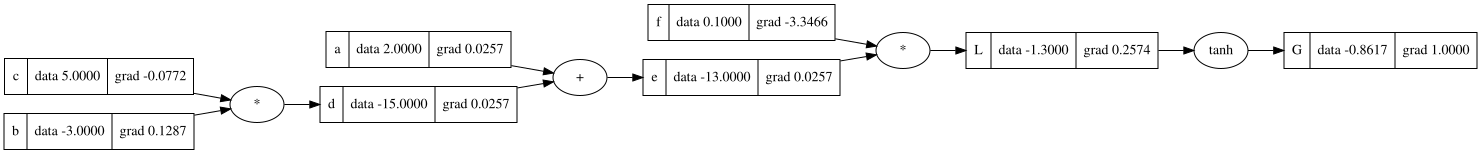

In [374]:
draw_dot(G)

In [375]:
import random

In [376]:
class Neuron:

  def __init__(self, nInp): # takes a number of inputs
   self.w = []
   for i in range(nInp):
    result = Value(random.uniform(-1,1))
    self.w.append(result) #self.w is a list of weights. Its elements have equal number to number of inputs
   self.b = Value(random.uniform(-1,1)) #self.b is a base

  def __call__(self,x):
   s = sum((xi*wi for xi,wi in zip(x, self.w)), self.b) # this zips all the elements of list x with all the weights it defined at init
   out = s.tanh() # tanh h gives an output between -1 to 1. Will update to ReLU for main project
   return out # returns a single output from multiple inputs

class Layer:

  def __init__(self, nInp, nOut): #takes a number of inputs, and assigns all of them to a list of nOut number of neutrons
   self.neurons = []
   for i in range(nOut):
    self.neurons.append(Neuron(nInp))

  def __call__(self, x):
   out = []
   for i in self.neurons:
    out.append(i(x)) #gives a list of neurons [ here i(x) calls the neuron]
   return out

class MLP:

   def __init__(self, sizes = []):
    self.sizes = sizes
    self.layers = []
    for i in range(len(sizes) - 1):
     self.layers.append(Layer(sizes[i], sizes[i+1])) #takes a list of layers, and makes it so that one layer's output become another layer's input

   def __call__(self, x):
    for layer in self.layers:
     x = layer(x) # so basically a layer takes the list of data, makes all neurons of that layer operate through that data, and returns a list of one or multiple outputs depending on what sizes[i+1]th element is, which becomes the next layer's input
    return x


x = [1,2,3]
n = MLP([3,2,3])


In [377]:
n(x)

[Value(data=0.9273814448742117),
 Value(data=-0.7276781243970192),
 Value(data=0.5804551088052476)]

In [378]:
l = n(x)
des = [1, 0, -1]
s = 0

for i in range(len(des)):
 s += (des[i] - l[i]).pow()
for a in range(len(n.layers)): #check all layers
 for b in range(len(n.layers[a].neurons)): #check all neurons
  for c in range(len(n.layers[a].neurons[b].w)): #all neurons' weights
   n.layers[a].neurons[b].w[c].grad = 0 #each weight's effect on data
   n.layers[a].neurons[b].grad = 0 #all grad 0 before backward gives an updated gradient


s.backward() #boom shakalaka

for i in range(len(des)):
 s += (des[i] - l[i]).pow()
for a in range(len(n.layers)):
 for b in range(len(n.layers[a].neurons)):
  n.layers[a].neurons[b].b.data += -0.01 * n.layers[a].neurons[b].b.grad #update all bias against the direction of gradient
  for c in range(len(n.layers[a].neurons[b].w)):
   n.layers[a].neurons[b].w[c].data += -0.01 * n.layers[a].neurons[b].w[c].grad #update all weights against the direction of gradient
s

Value(data=6.065254516446256)

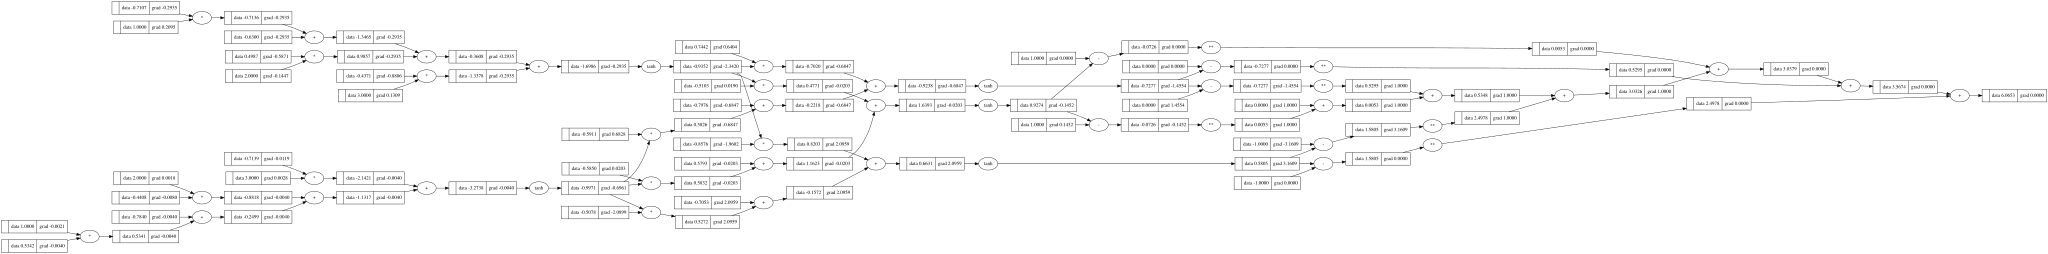

In [379]:
draw_dot(s)